In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Generalizing the tower problem

In the previous module, we considered the (linear) tower problem, which we eventually wrote in the form

$$
\begin{align*}
    \underset{h}{\text{minimize}}\quad& \sum_{\{i,j\}\in E}\sigma_{ij}\big|h_i-h_j\big|\\
    \text{subject to}\quad & h_0 = 0,\;h_{n-1}=1
\end{align*}
$$

Recall that $E$ is the edge set of a weighted undirected graph $G=(V,E,\sigma)$ with $\sigma:E\to(0,\infty)$ giving the edge weights.  (For an edge $e=\{i,j\}\in E$, we can write the associated edge weight as $\sigma(e)$ or $\sigma(i,j)$ or $\sigma_{ij}$, whichever is most notationally convenient.)  At the end of the previous notebook, we had a brief glimpse of a related (quadratic) tower problem.  In fact, there is a whole family of tower problems, parameterized by a number $p\in[1,\infty)$.  For such a $p$, let's define the *$p$-tower problem* as

$$
\begin{align*}
    \underset{h}{\text{minimize}}\quad& \sum_{\{i,j\}\in E}\sigma_{ij}\big|h_i-h_j\big|^p\\
    \text{subject to}\quad & h_0 = 0,\;h_{n-1}=1
\end{align*}
$$

## Why require $p\ge 1$?

You may wonder why we would restrict $p\ge 1$.  Certainly, the problem appears to make sense for any $p>0$.  The short answer is this. For $p\ge 1$, the $p$-tower problem is a convex optimization problem, but for $p<1$, the objective is no longer a convex function.  Much of the current theory about this problem relies on convex optimization theory, so the $p\ge 1$ case is the one we can say the most about.  That's not to say that $0\lt p\lt 1$ might not be incredibly interesting, but the methods used in this notebook won't immediately apply to those cases.

## The case $p>1$

Since we dealt with the $1$-tower problem in the last module, we'll focus on $p>1$ in this notebook.  For $p>1$, the $p$-tower problem is not only a convex optimization problem, it is also *smooth* in the sense that the objective function and constraints are continuously differentiable.  You can verify that, for $p>1$, the function $f(x)=|x|^p$ is differentiable, with derivative

$$
    f'(x) = p\,\text{sgn}(x)\,|x|^{p-1},
$$

where $\text{sgn}$ is the [sign function](https://en.wikipedia.org/wiki/Sign_function).

This means that we can use the theory of Lagrange multipliers (just a special case of Lagrangian duality when there are no inequality constraints) to solve the $p$-tower problem for $p>1$.  To do so, we introduce the Lagrange multipliers $\lambda_0$ and $\lambda_{n-1}$ and write the Lagrangian as

$$
    \mathcal{L}(h,\lambda) = \sum_{\{i,j\}\in E}\sigma_{ij}\big|h_i-h_j\big|^p + \lambda_0 h_0 + \lambda_{n-1}(1-h_{n-1}).
$$

The partial derivative of $\mathcal{L}$ with respect to one of the variables $h_k$ is

$$
    \frac{\partial\mathcal{L}}{\partial h_k} = p \sum_{j\sim k} \sigma_{kj} \text{sgn}(h_k-h_j)\big|h_k-h_j\big|^{p-1}
    + \delta_{k,0}\lambda_0 - \delta_{k,{n-1}}\lambda_{n-1},
$$

where $\delta$ is the [Kronecker delta](https://en.wikipedia.org/wiki/Kronecker_delta).  In other words, the partial derivatives are

$$
\begin{align*}
    \frac{\partial\mathcal{L}}{\partial h_0} &= p \sum_{j\sim 0} \sigma_{0j} \text{sgn}(h_0-h_j)\big|h_0-h_j\big|^{p-1}
    + \lambda_0,\\
    \frac{\partial\mathcal{L}}{\partial h_1} &= p \sum_{j\sim 1} \sigma_{1j} \text{sgn}(h_1-h_j)\big|h_1-h_j\big|^{p-1},\\
    \frac{\partial\mathcal{L}}{\partial h_2} &= p \sum_{j\sim 2} \sigma_{2j} \text{sgn}(h_2-h_j)\big|h_2-h_j\big|^{p-1},\\
    &\vdots\\
    \frac{\partial\mathcal{L}}{\partial h_{n-1}} &= p \sum_{j\sim n-1} \sigma_{n-1,j} \text{sgn}(h_{n-1}-h_j)\big|h_{n-1}-h_j\big|^{p-1} - \lambda_{n-1}.
\end{align*}
$$

So, to solve the $p$-tower problem, we could solve the system of nonlinear equations

$$
\begin{gather*}
p \sum_{j\sim k} \sigma_{kj} \text{sgn}(h_k-h_j)\big|h_k-h_j\big|^{p-1}
    + \delta_{k0}\lambda_0 - \delta_{k,{n-1}}\lambda_{n-1} = 0\qquad j=0,1,\ldots,n-1,\\
    h_0 = 0, \qquad h_{n-1} = 1.
\end{gather*}
$$

## $p=2$ is special

If you think back to Math 725, this system may look familiar.  In the special case $p=2$,

$$
p \sum_{j\sim k} \sigma_{kj} \text{sgn}(h_k-h_j)\big|h_k-h_j\big|^{p-1}
= 2 \sum_{j\sim k} \sigma_{kj} (h_k-h_j) = 2 Lh,
$$

where $L$ is the (weighted) graph Laplacian.  So the Lagrange system for the $2$-tower problem takes the simpler form

$$
\begin{gather*}
    2Lh + \delta_{0}\lambda_0 - \delta_{{n-1}}\lambda_{n-1} = 0\qquad j=0,1,\ldots,n-1,\\
    h_0 = 0, \qquad h_{n-1} = 1.
\end{gather*}
$$

This is simply the problem of finding the electric current flowing through the network when a 1V battery is connected between node $0$ and node $n-1$, which is exactly why we saw, at the end of the previous notebook, that the solution to the $2$-tower problem gave the effective conductance between $0$ and $n-1$.

# A cvxpy implementation

Here's a way to reformulate the $p$-tower problem to make it easier to solve with cvxpy.  We'll start with an example modified from the last notebook.

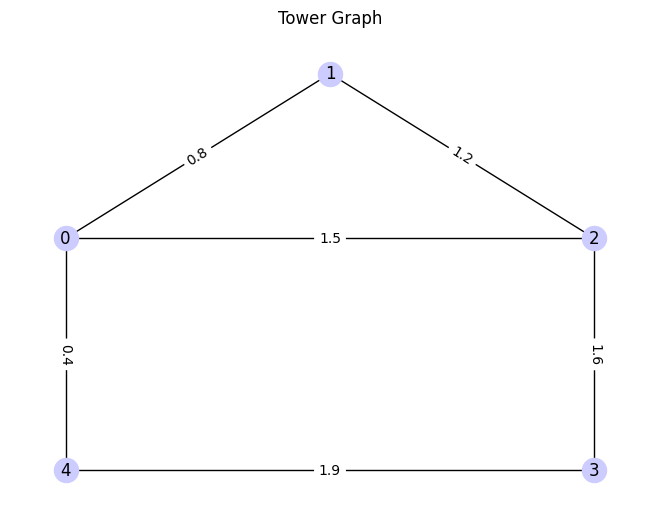

In [2]:
def draw_tower_graph(G,pos,label='sigma'):
    """
    Draws a graph representing the tower problem.

    Args:
        G:   A NetworkX graph with 'sigma' (or whatever label is
             set to) values attached to each edge.
        pos: A position dictionary for plotting.

    Returns:
        Nothing
    """
    
    # fetch edge labels
    lbl = { (u,v):d[label] for u,v,d in G.edges(data=True) }
    
    # draw the graph
    nx.draw(G,pos,with_labels=True,node_color='#ccccff')
    
    # label edges
    nx.draw_networkx_edge_labels(G,pos,edge_labels=lbl)

###################################
# create and draw the tower example

edges = [(0, 1, {'sigma': 0.8}), (1, 2, {'sigma': 1.2}), (2, 3, {'sigma': 1.6}),
         (3, 4, {'sigma': 1.9}), (4, 0, {'sigma': 0.4}), (0, 2, {'sigma': 1.5})]

pos = {0: (0, 0), 1: (0.5,0.71), 2: (1, 0), 3: (1, -1), 4: (0, -1)}

G = nx.Graph(edges)
draw_tower_graph(G,pos)
plt.title('Tower Graph');

## Enumerating the edges

As usual, it helps to enumerate the edges so that we can write the edge set as $E=\{e_0,e_1,\ldots,e_{m-1}\}$.  (As with the vertices, we're enumerating starting at $0$ rather than $1$ because it matches better with the way Python indexes lists.)

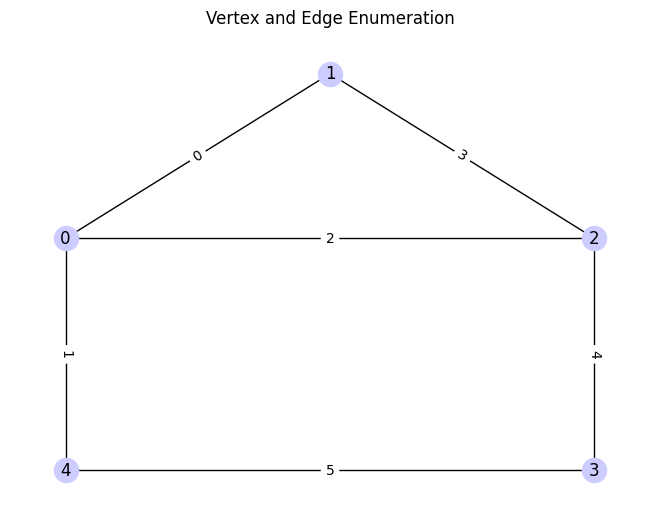

In [3]:
def enumerate_edges(G):
    """
    Enumerates the edges of a graph.

    Args:
        G: The Networkx graph.

    Returns:
        Nothing.

    On exit, each edge of the graph G will have an attached property
    called 'enum' holding the index of that edge in G.edges().
    """
    
    for i,(u,v) in enumerate(G.edges()):
        G[u][v]['enum'] = i
        
# enumerate the edges of G
enumerate_edges(G)

# draw the edge enumeration
draw_tower_graph(G,pos,'enum')
plt.title('Vertex and Edge Enumeration');

## Forming the gradient

Next, let's review from Math 725 how to form the *gradient* matrix $B$.  We start by choosing an *orientation* for each edge.  Let $e$ be any edge in $E$.  Then $e$ connects exactly 2 vertices, call them $i$ and $j$.  For each edge, we're going to arbitrarily pick one of those two vertices to call the "source" of the edge and the other to call the "target".  It doesn't actually matter how we pick this orientation, as long as we don't change our minds partway through a computation.

Once we've selected an orientation, we define the $m\times n$ gradient matrix $B$ as

$$
    B_{ij} =
    \begin{cases}
        1 & \text{if node $j$ is the target of edge $i$}\\
        -1 & \text{if node $j$ is the source of edge $i$}\\
        0 &\text{otherwise}
    \end{cases}
$$

Since each edge in $E$ can be given one of 2 orientations, there are actually $2^m$ possible gradient matrices.  Let's assume we've picked one and call it *the* gradient from now on.

It's also helpful to define the $n\times n$ *weight matrix* $\Sigma = \text{diag}\left(\sigma(e_0),\sigma(e_1),\ldots,\sigma(e_{m-1})\right)$.  In other words $\Sigma$ is a diagonal matrix with entries

$$
    \Sigma_{ii} = \sigma(e_i),\quad\text{ the weight of the $i$th edge.}
$$

One interesting fact about the gradient that we saw in Math 725 is that $L = B^T\Sigma B$.  (If all edge weights are $1$, then $\Sigma=I$ and $L=B^TB$.)  It's a fun exercise to check that this fact is true no matter which of the $2^m$ possible gradients we choose.

Here's some code to build the gradient.  (It just picks the orientation based on the order in which NetworkX stores the edge endpoints internally.)  Compare the gradient matrix to the graph to make sure you understand why the entries are what they are.

B = 
[[-1.  1.  0.  0.  0.]
 [-1.  0.  0.  0.  1.]
 [-1.  0.  1.  0.  0.]
 [ 0. -1.  1.  0.  0.]
 [ 0.  0. -1.  1.  0.]
 [ 0.  0.  0. -1.  1.]]


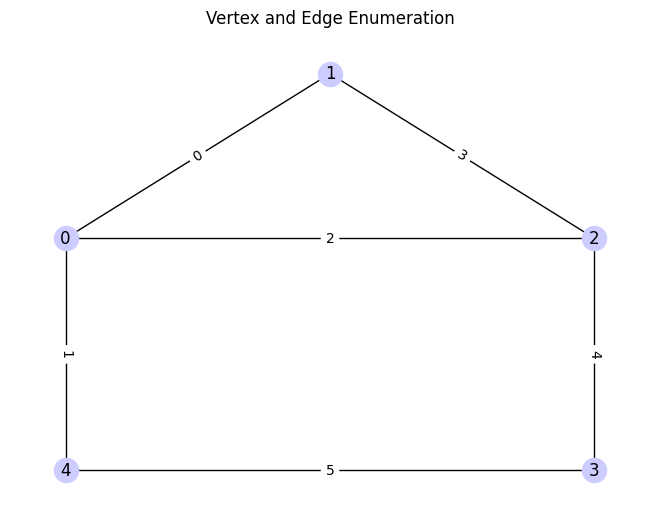

In [4]:
def gradient(G):
    """
    Generates the gradient matrix for G.

    Args:
        G: The Networkx graph.

    Returns:
        B: The gradient as a numpy array.
    """
    
    import numpy as np
    
    # get dimensions
    m = len(G.edges())
    n = len(G.nodes())
    
    # initialize B
    B = np.zeros((m,n))
  
    # loop over edges
    for edge_id,(a,b) in enumerate(G.edges()):
        
        # treat a as the source
        B[edge_id,a] = -1
        
        # treat b as the target
        B[edge_id,b] = 1
        
    # create the gradient
    return B



# print the example gradient
print('B = ')
print(gradient(G))

# draw the example graph
draw_tower_graph(G,pos,'enum')
plt.title('Vertex and Edge Enumeration');

## Forming the objective function

Here's the $p$-tower problem again.

$$
\begin{align*}
    \underset{h}{\text{minimize}}\quad& \sum_{\{i,j\}\in E}\sigma_{ij}\big|h_i-h_j\big|^p\\
    \text{subject to}\quad & h_0 = 0,\;h_{n-1}=1
\end{align*}
$$

It's going to be easy to give cvxpy the two constraints, but how should we express the objective?  First, notice that the objective can be written like this:

$$
    \sum_{e\in E}\sigma(e)\big|(Bh)(e)\big|^p = \sum_{i=0}^{m-1}\sigma(e_i)\big|(Bh)(e_i)\big|^p,
$$

where $(Bh)(e)$ is the entry in the vector $Bh$ corresponding to edge $e$.  If you check the [cvxpy documentation](https://www.cvxpy.org/tutorial/functions/index.html#scalar-functions), you'll see a function called ```pnorm``` that can compute, for a vector $x$, the quantity

$$
    \|x\|_p = \left(\sum_{i}\left|x_i\right|^p\right)^{1/p}.
$$

That's close to what we want.  Here's how we can use it.  If we keep in mind that the $\sigma(e)$ are all positive, we can write the objective as

$$
    \sum_{i}\sigma(e_i)\big|(Bh)(e_i)\big|^p = 
    \sum_{i}\big|\sigma(e_i)^{1/p}(Bh)(e_i)\big|^p
    =\|\Sigma^{1/p}Bh\|_p^p,
$$

where $\Sigma^{1/p}$ is the diagonal matrix with entries $\sigma(e_i)^{1/p}$.  The following code shows how to generate $\Sigma$ and $\Sigma^{1/p}$.

In [5]:
def sigma_matrix(G):
    """
    Generates the diagonal sigma matrix for G.

    Args:
        G: The Networkx graph.

    Returns:
        Sigma: A diagonal numpy array of edge weights.
    """
    
    import numpy as np
    
    return np.diag( [d['sigma'] for a,b,d in G.edges(data=True)] )





#####################
# Example
    
# form Sigma
S = sigma_matrix(G)

print('Sigma = ')
print(S)
print()

# form Sigma^(1/3) as an example
print('Sigma^{1/3} =')
print(S**(1./3))

Sigma = 
[[0.8 0.  0.  0.  0.  0. ]
 [0.  0.4 0.  0.  0.  0. ]
 [0.  0.  1.5 0.  0.  0. ]
 [0.  0.  0.  1.2 0.  0. ]
 [0.  0.  0.  0.  1.6 0. ]
 [0.  0.  0.  0.  0.  1.9]]

Sigma^{1/3} =
[[0.92831777 0.         0.         0.         0.         0.        ]
 [0.         0.7368063  0.         0.         0.         0.        ]
 [0.         0.         1.14471424 0.         0.         0.        ]
 [0.         0.         0.         1.06265857 0.         0.        ]
 [0.         0.         0.         0.         1.1696071  0.        ]
 [0.         0.         0.         0.         0.         1.23856233]]


## A solver

### 💻 Exercise

Use the ingredients above to implement the $p$-tower solver below.

**Hint:** Keep in mind that the objective is *not* $\|\Sigma^{1/p}Bh\|_p$, it is $\|\Sigma^{1/p}Bh\|_p^p$.

In [6]:
def solve_1(G,p):
    """
    Solves the generalized Mars tower problem.
    
    Args:
        G: The graph representation of the problem.
        p: The problem exponent.  p >= 1

    Returns:
        c, h:
            - c is the optimal cost
            - h is a numpy array holding the solutuion h[i] = h_i

    On entry, each edge on the graph should have an attached attribute
    called 'sigma' giving the cost per unit distance of separating the
    two nodes connected by the edge.
    """
    
    import cvxpy as cvx
    
    # dimensions
    m = len(G.edges())
    n = len(G.nodes())
    
    # optimization variables
    h = cvx.Variable(n)

    # enumerate the edges
    enumerate_edges(G)
    
    # YOUR CODE HERE
    obj_expr = cvx.norm((sigma_matrix(G)**(1/p)) @ gradient(G) @ h, p)**p
    obj = cvx.Minimize(obj_expr)
    cons = [h[0]==0, h[n-1]==1]
    
    # set up the problem
    prob = cvx.Problem(obj,cons)
    
    # solve the problem
    prob.solve()
    
    # check the status
    assert( prob.status == 'optimal' )
        
    return obj.value, np.array(h.value).flatten()

In [7]:
def test_solution(G,p,c,h):
    """
    Verifies that the tower configuration h has cost c.

    Args:
        G: The graph representation of the problem.
        p: The p parameter.
        c: The (alleged) cost.
        h: The tower configuration (as a numpy vector).

    Returns:
        Nothing.
        
    Raises an assertion error if the solution is infeasible or does not have
    cost c.
    """
    
    from numpy.testing import assert_almost_equal
    
    # check the "boundary conditions"
    assert_almost_equal(h[0],0,decimal=5)
    assert_almost_equal(h[-1],1,decimal=5)
    
    # compute the cost directly from the graph
    cost = 0.
    for i,j,d in G.edges(data=True):
        cost += d['sigma'] * abs( h[i] - h[j] )**p
        
    # check the cost
    assert_almost_equal(cost,c,decimal=5)


def test_solver(solver):

    # test parameters
    ns = range(3,7)
    ps = [1.0, 1.75, 2.0, 2.8]

    import itertools as it

    ######################
    # tests on path graphs

    for n,p in it.product(ns,ps):

        # build the graph
        H = nx.path_graph(n)
        for a,b in H.edges():
            H[a][b]['sigma'] = 1

        # solve
        c,h = solver(H,p)
        
        # test the solution
        test_solution(H,p,c,h)

        # true value
        t = (n-1)**(1-p)

        # compare
        if abs(t-c) > 1e-5*t:
            raise RuntimeError('Error on P_n for n={}, p={}: expected {}, got {}'.format(n,p,t,c))
            
    
    ##########################
    # tests on complete graphs

    for n,p in it.product(ns,ps):
        
        # build the graph
        H = nx.complete_graph(n)
        for a,b in H.edges():
            H[a][b]['sigma'] = 1

        # solve
        c,h = solver(H,p)
        
        # test the solution
        test_solution(H,p,c,h)


        # true value
        t = 1 + (n-2)/2**(p-1)

        # compare
        if abs(t-c) > 1e-5*t:
            raise RuntimeError('Error on K_n for n={}, p={}: expected {}, got {}'.format(n,p,t,c))
            
            
    ###################
    # series rule tests
    
    s1, s2 = 0.8, 1.95
    for p in ps:
        
        if p == 1:
            continue
        
        # build the graph
        H = nx.path_graph(3)
        H[0][1]['sigma'] = s1
        H[1][2]['sigma'] = s2
        
        # solve
        c,h = solver(H,p)
        
        # test the solution
        test_solution(H,p,c,h)
        
        # true solution
        r = 1./(p-1)
        t = s1*s2/(s1**r+s2**r)**(p-1)
        
        # compare
        if abs(t-c) > 1e-5*t:
            raise RuntimeError('Error on series rule, p={}: expected {}, got {}'.format(p,t,c))
        
test_solver(solve_1)
print('All tests passed.')

All tests passed.


Here is a visualization of some solutions to our tower problem with different values of $p$.  Edges are colored using the value $\sigma(e)\big|(Bh)(e)\big|^p$.  If you imagine current flowing in a (nonlinear) resistor network, this value can be interpreted as the amount of power dissipated by the resistor on edge $e$, or, in other words, how "hot" that resistor is.  The pinkish edges are hotter than the blueish ones.  Since the objective function is just the total dissipated power from all resistors, the hotter edges are the ones contributing the most to the final objective value.  Notice how the hottest edge changes as $p$ varies.

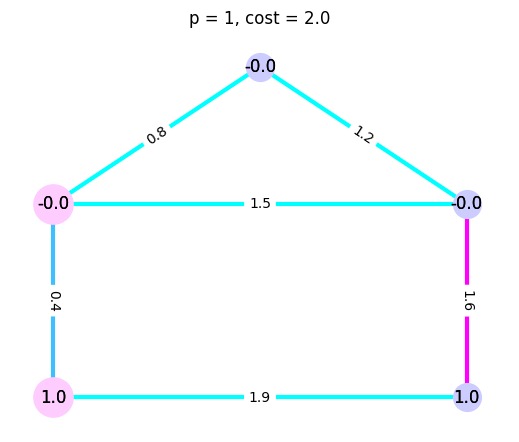

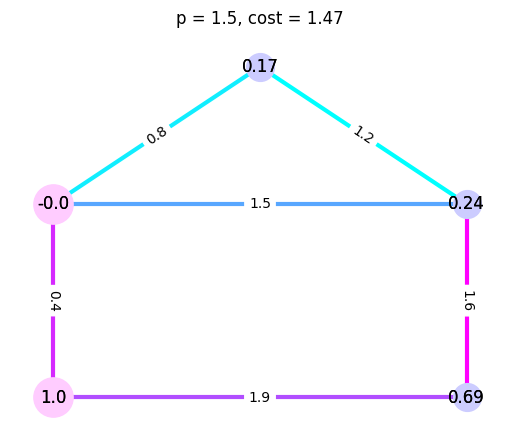

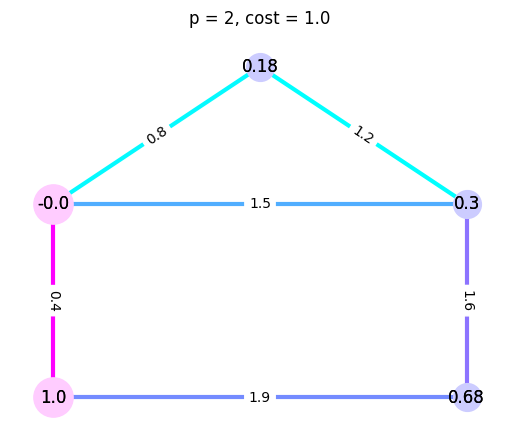

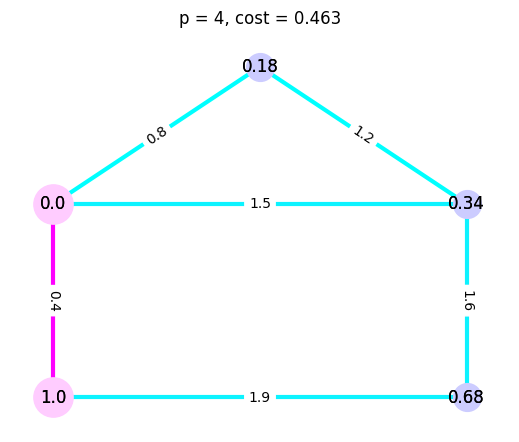

In [8]:
def draw_tower_solution(G,pos,h,p):
    """
    Visualizes a solution to the tower problem on a graph

    Args:
        G:   The graph representation of the problem.
        pos: Position dictionary for plotting.
        h:   The optimal tower height arrangement.
        p:   The p exponent.

    Returns:
        Nothing.
    """
    
    import matplotlib.pyplot as plt
    import networkx as nx
    
    # number of nodes
    n = len(G.nodes())
    
    plt.figure(figsize=(5,4))
    
    # fetch node labels
    lbl = { v:round(h[v],2) for v in G.nodes()  }
    
    # draw the graph
    nx.draw(G,pos,labels=lbl,node_color='#ccccff',node_size=400)
    
    # hilight end nodes
    nx.draw(G,pos,labels=lbl,nodelist=[0,n-1],node_color='#ffccff',node_size=800)
            
    # compute the potential drop across edges
    rho = [ d['sigma']*abs(h[u]-h[v])**p for u,v,d in G.edges(data=True) ]
    nx.draw_networkx_edges(G,pos,edge_color=rho,width=3,edge_cmap=plt.cm.cool)
    
    # fetch edge labels
    lbl = { (u,v):d['sigma'] for u,v,d in G.edges(data=True) }

    # draw edge labels
    nx.draw_networkx_edge_labels(G,pos,edge_labels=lbl)
    

for p in [1,1.5,2,4]:
    c,h = solve_1(G,p)    
    draw_tower_solution(G,pos,h,p)
    plt.title('p = {}, cost = {:.3}'.format(p,c))

# The path formulation and modulus

Just as in the case of the original ($p=1$) tower problem, the general tower problem can also be rewritten in path form:

$$
    \begin{align*}
    \underset{\rho}{\text{minimize}}\quad&\sum_{\{i,j\}\in E}\sigma_{ij}\rho_{ij}^p\\
    \text{subject to}\quad& \rho_{ij}\ge 0\;\forall\{i,j\}\in E\\
    & \ell_\rho(\gamma)\ge 1\;\forall\gamma\in\Gamma,
    \end{align*}
$$

where $\Gamma$ is the family of simple paths from $0$ to $n-1$.

Introducing the $\mathcal{N}$ matrix from the last notebook, the path formulation can be written as

$$
    \begin{align*}
    \underset{\rho}{\text{minimize}}\quad&\|\Sigma^{1/p}\rho\|_p^p\\
    \text{subject to}\quad& \rho\ge \mathbf{0}\\
    & \mathcal{N}\rho\ge\mathbf{1}.
    \end{align*}
$$

This is one example of something called a *$p$-modulus problem*.  We'll see more of these in later modules.  Basically, any problem that takes the above form with some non-negative matrix $\mathcal{N}$ is a $p$-modulus problem; the $p$-tower problem fits neatly inside this larger class of problems.

## Working with the $\mathcal{N}$ matrix

The $\mathcal{N}$ matrix above is called the *usage* matrix because it reports, for each path and each edge, whether the path uses the edge.  That is, $\mathcal{N}_{ij}=1$ if path $i$ crosses edge $j$ and $\mathcal{N}_{ij}=0$ otherwise.  Every row of $\mathcal{N}$ is the *usage vector* associated with a particular path.  As we build a modulus solver, we're going to need a function to convert a path (given as a list of vertices visited) into a vector.  The following function does that.  Make sure you understand the examples below before continuing.

Examples
path =  [0, 4]
v    =  [0. 1. 0. 0. 0. 0.]

path =  [0, 2, 3, 4]
v    =  [0. 0. 1. 0. 1. 1.]

path =  [0, 1, 2, 3, 4]
v    =  [1. 0. 0. 1. 1. 1.]



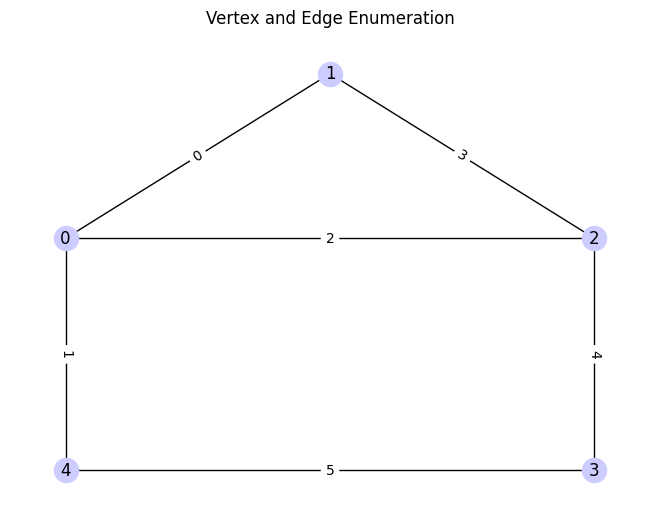

In [9]:
def vectorize_path(G,path):
    """
    Converts a path on a graph into a usage vector.

    Args:
        G:    The NetworkX graph.
        path: List of vertices 

    Returns:
        The usage vector.

    The edges of G are assumed to be enumerated with an 'enum' attribute.
    """
    
    import numpy as np

    # count the edges in the graph
    m = len(G.edges())
    
    # initialize the usage vector
    v = np.zeros(m)
    
    # loop over edges in the path
    for i in range( len(path) - 1 ):
        
        # here's the edge
        a, b = path[i], path[i+1]
        
        # find its enumeration index
        ind = G[a][b]['enum']
        
        # update the vector
        v[ind] = 1
        
    return v





#######################
# usage vector examples

print('Examples')
print('===============================')
for path in [ [0,4], [0,2,3,4], [0,1,2,3,4] ]:
    print('path = ', path)
    print('v    = ', vectorize_path(G,path))
    print()
    
# draw the example graph
draw_tower_graph(G,pos,'enum')
plt.title('Vertex and Edge Enumeration');

## A simple general modulus solver

### 💻 Exercise

Implement the $p$-modulus solver below.  Notice that you are given the $\mathcal{N}$ matrix, the exponent $p$ and the vector $\sigma$.  (The function doesn't need to know anything about the graph that this problem arose from!)  You need to tell cvxpy about the constraints $\rho\ge\mathbf{0}$ and $\mathcal{N}\rho\ge 1$, which can be done on one short line.  You can modify your objective function from earlier to use in this function.

In [10]:
def modulus(N,p,sigma):
    """
    Computes p-modulus.
    
    Args:
        N:     The N matrix as a numpy array.
        p:     The exponent p>=1.
        sigma: The vector of weights sigma.

    Returns:
        mod, rho
            - mod: The value of the modulus.
            - rho: The optimal rho vector.
    """
    
    import cvxpy as cvx
    import numpy as np
    
    # number of rho variables
    n = N.shape[-1]
    
    # make sigma into a diagonal matrix
    S = np.diag(sigma)
    
    # set up optimization variables
    rho = cvx.Variable(n)
    
    # YOUR CODE HERE
    cons = [rho>=0, N@rho>=1]
    obj = cvx.Minimize(cvx.norm(rho@S**(1/p),p)**p)
    
    # solve the problem
    prob = cvx.Problem(obj,cons)
    prob.solve(solver='ECOS')
    
    return obj.value, np.array(rho.value).flatten()

In [11]:
###########
# test data
ps = [2.4554252194941, 2.9719523814213487, 3.692703499215513, 3.9199235624317392, 1.1762580941106435]
Ns = [[[0.0, 0.0, 1.0, 0.0, 1.0], [0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 1.0, 1.0, 0.0, 0.0], 
       [0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 1.0, 1.0, 1.0, 1.0], [1.0, 0.0, 0.0, 0.0, 1.0]], 
      [[1.0, 0.0, 1.0, 1.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [0.0, 1.0, 1.0, 0.0]], 
      [[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0]], 
      [[1.0, 0.0, 0.0, 1.0], [0.0, 0.0, 0.0, 1.0], [1.0, 1.0, 1.0, 0.0], [0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0]], 
      [[1.0, 0.0, 0.0, 0.0, 0.0, 1.0], [0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 0.0, 1.0, 1.0, 1.0], 
       [1.0, 1.0, 0.0, 1.0, 1.0, 1.0], [0.0, 1.0, 0.0, 1.0, 1.0, 0.0], [0.0, 1.0, 1.0, 0.0, 1.0, 0.0]]]
sigmas = [[0.61082774, 0.93691013, 0.7970157 , 0.65296573, 0.61339288], 
          [0.32880051, 0.23897015, 0.11252122, 0.16383902], 
          [0.99091039, 0.2885902 , 0.08352669, 0.84147953, 0.26747546, 0.6103545 , 0.20877175], 
          [0.3653845 , 0.13230189, 0.71558816, 0.67349371], 
          [0.69986161, 0.62499049, 0.99148722, 0.90887259, 0.00259845, 0.89271423]]
mods = [1.1041221632895015 ,0.3514893629567281 ,0.30178708877786276 ,1.7544493303947766 ,1.297730274561084]

# run the tests
ntests = len(ps)
for t in range(ntests):
    N = np.array(Ns[t])
    sigma = np.array(sigmas[t])
    mod,rho = modulus(N, ps[t], sigma)
    if abs(mod - mods[t]) > 1.e-4:
        raise ValueError( 'in test {}, got mod = {}, expected {}'.format(t, mod,mods[t]) )
        
print('All tests passed.')

All tests passed.


## Solving the $p$-tower problem again

Now let's see how to solve the $p$-tower problem with the help of the modulus solver above and the $\rho$-to-$h$ conversion algorithm from the last notebook.  The idea is straightforward, but we are glossing over one issue: showing that the two problems are actually equivalent.  The previous notebook hopefully gave you some insight into why they are equivalent. From $h$, you get $\rho$ by setting $\rho_{ij}=\big|h_i-h_j\big|$ on each edge.  From $\rho$ you can get back to $h$ by defining $h_i$ as the length of the shortest path (measured by $\rho$) from node $0$ to node $i$.  You can find more details in [this paper](http://www.ams.org/journals/ecgd/2015-19-13/S1088-4173-2015-00287-8/), which is coauthored by three former K-State REU participants.  (Take a look at Theorem 4.2.  It should look familiar.)

### 💻 Exercise

Complete the implementation of the $p$-tower solver (```solve_2```) below, using your ```modulus``` function to solve for $\rho$ and the ```rho_to_h``` function to convert $\rho$ to $h$.  You'll probably also want to use the ```vectorize_path``` function to help you fill in the rows of $\mathcal{N}$.

In [12]:
def rho_to_h(G,rho):
    """
    Converts rho to h for the Mars tower problem.
    
    Args:
        G:   The NetworkX graph.
        rho: The optimal rho from the modulus formulation.
        
    Returns:
        h: The optimal h.
    """
    
    import numpy as np
    
    # number of nodes
    n = len(G.nodes())
    
    # initialize h
    h = np.zeros(n)
    
    # loop over edges to attach 'rho' attribute
    for u,v in G.edges():
        
        # edge enumeration
        enum = G[u][v]['enum']
        
        # set rho on the edge
        G[u][v]['rho'] = max(0,rho[enum])
    
    # loop over nodes
    for u in G.nodes():

        # compute the distance from 0 to u using rho
        h[u] = nx.shortest_path_length(G,0,u,'rho')
        
    return h


def solve_2(G,p):
    """
    Solves the generalized Mars tower problem.
    
    Args:
        G: The graph representation of the problem.
        p: The problem exponent.  p >= 1

    Returns:
        c,h:
            - c is the optimal cost
            - h is a numpy array holding the solutuion h[i] = h_i

    On entry, each edge on the graph should have an attached attribute
    called 'sigma' giving the cost per unit distance of separating the
    two nodes connected by the edge.
    """
    
    import networkx as nx
    import numpy as np
    
    # count the number of nodes edges
    n = len(G.nodes())
    m = len(G.edges())
    
    # enumerate the edges of G
    enumerate_edges(G)
    
    # extract sigma vector from the graph
    sigma = np.array( [d['sigma'] for a,b,d in G.edges(data=True)] )

    # get all simple paths
    paths = list(nx.all_simple_paths(G,0,n-1))
    
    # count the number of paths
    n_paths = len(paths)
    
    # initialize N matrix
    N = np.zeros((n_paths,m))
    
    # YOUR CODE HERE
    for i,path in enumerate(paths):
        N[i] = vectorize_path(G,path)
    mod, rho = modulus(N, p, sigma)
    h = rho_to_h(G, rho)
    return mod, h

In [13]:
test_solver(solve_2)
print('All tests passed.')

All tests passed.


## The problem with $\mathcal{N}$

Now for some bad news.  Both the original formulation of the $p$-tower problem and the $p$-modulus formulation are convex optimization problems, which means that we have access to some powerful computational tools to solve either one.  The main difference between the two lies in the number of variables and constraints.

Let's start with the original formulation of the $p$-tower problem.  To solve this problem, we need to find the values $h_i$ for $i=0,1,\ldots,n-1$, so there are $n$ optimization variables and $2$ equality constraints.  (Or we could substitute the known values for $h_0$ and $h_{n-1}$ directly into the objective function and get an unconstrained optimization problem in $n-2$ variables.)

Now let's consider the $p$-modulus formulation.  In this formulation, we need to choose the values $\rho_{ij}$ for each $\{i,j\}\in E$.  Thus, we have one unknown quantity for each edge in $E$.  Since we are assuming that $G$ is a simple connected graph, it's possible to prove that

$$
    n-1 \le |E| \le \frac{n(n-1)}{2}\approx\frac{1}{2}n^2.
$$

So, for general graphs, we should expect that the $p$-modulus formulation has many more optimization variables than the original formulation.  That's not great news, but it's better than what happens when we look at the number of constraints.

In the $p$-modulus formulation, there is one constraint ($\ell_{\rho}(\gamma)\ge 1$) for each simple path $\gamma\in\Gamma$.  In the solver above, we used NetworkX's ```all_simple_paths``` function without really thinking about how many paths it was going to return.  Let's see if we can figure out how many simple paths exist between nodes $0$ and $n-1$.

With a little thought, you should be able to convince yourself that the worst case is when $G$ is the complete graph $K_n$.  In $K_n$ there are *lots* of simple paths from $0$ to $n-1$.  Let's focus on a special subset of these: the Hamiltonian paths (i.e., the paths that start at $0$, end at $n-1$, and pass through every other node along the way).  Since there is an edge between every pair of nodes in $K_n$, we can visit the intermediate nodes in any order we wish to build a Hamiltonian path.  On our first step, we have $n-2$ options to visit next.  On our second step, we have $n-3$ options, and so on.  Since the Hamiltonian paths are a subset of all simple paths, we can estimate that, for the complete graph,

$$
    \big|\Gamma\big| \ge (n-2)!.
$$

For $n=12$, there are more than 3 million constraints; for $n=17$ there are more than 1 trillion; for $n=72$ there are more than 1 googol!

So, here's the problem: how are we going to solve an optimization problem when it might take us billions of years (or more!) just to generate the $\mathcal{N}$ matrix?  (And where would we store that many numbers anyway?)  We'll figure out how to deal with this in the next notebook.